<a href="https://colab.research.google.com/github/MSagri05/Assignment-03-Unsupervised-Learning-Classical-NLP/blob/main/Assignment_3_Unsupervised_Learning_%26_Classical_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Unsupervised Learning
## Vancouver Business Licences Explorer

**Course:** IAT 461

**Student:** Manmeet Sagri (301545311)

## 1. Import Libraries

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

plt.style.use("default")

## 2. Load the Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Convert the GeoJSON File into a DataFrame

In [3]:
file_path = "/content/drive/MyDrive/business-licences.geojson"

with open(file_path, "r") as f:
    geojson = json.load(f)

print(type(geojson))
print(geojson.keys())

<class 'dict'>
dict_keys(['type', 'features'])


In [4]:
rows = []

for feature in geojson["features"]:
    properties = feature["properties"]

    geometry = feature.get("geometry")

    if geometry and geometry["type"] == "Point":
        lon, lat = geometry["coordinates"]
    else:
        lon, lat = None, None

    rows.append({
        **properties,
        "longitude": lon,
        "latitude": lat
    })

df = pd.DataFrame(rows)

## 4. Initial Data Exploration

In [5]:
df.head()

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geo_point_2d,longitude,latitude,geom
0,26,4944875,26-202017,00,1554429 B.C. LTD.,ULTRAMARINOS PEPE,Issued,2026-05-25T13:27:38-06:00,2026-12-31,Limited Service Food Establishment,...,None,V5Z 1S6,South Cambie,2.0,559.0,2026-07-25T01:09:02-06:00,"{'lon': -123.119718378987, 'lat': 49.256859194...",-123.119718,49.256859,NaN
1,26,4944879,26-202021,00,TELUS HEALTH CARE CENTRES INC. / CLINIQUES TEL...,X-Ray 505,Issued,2026-03-23T16:56:24-06:00,2026-12-31,Laboratory Services,...,None,V5Z 1H4,Fairview,48.0,308.0,2026-07-25T01:09:02-06:00,"{'lon': -123.121054317485, 'lat': 49.263014530...",-123.121054,49.263015,NaN
2,26,4944884,26-202026,00,ROSLYN PLACE APTS. LTD.,None,Issued,2026-02-27T15:28:19-07:00,2026-12-31,Long-term Rental,...,None,V5N 5R2,Grandview-Woodland,0.0,5369.0,2026-07-25T01:09:02-06:00,"{'lon': -123.071106732275, 'lat': 49.265351363...",-123.071107,49.265351,NaN
3,26,4944901,26-202043,00,CAN-ACHIEVE EDUCATION&CULTURE INC.,Allway Solutions,Issued,2026-02-23T17:18:41-07:00,2026-12-31,Business Support Services,...,None,V5X 0C3,Marpole,6.0,254.0,2026-07-25T01:09:02-06:00,"{'lon': -123.115976004173, 'lat': 49.210010909...",-123.115976,49.210011,NaN
4,26,4944903,26-202045,00,THE LONG TOQUE CLUB,None,Cancelled,None,None,Association or Society,...,CA,None,Mount Pleasant,1.0,NaN,2026-07-25T01:09:02-06:00,None,NaN,NaN,NaN


### 4.1 Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204259 entries, 0 to 204258
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   folderyear             204259 non-null  object 
 1   licencersn             204259 non-null  object 
 2   licencenumber          204259 non-null  object 
 3   licencerevisionnumber  204259 non-null  object 
 4   businessname           190777 non-null  object 
 5   businesstradename      77378 non-null   object 
 6   status                 204259 non-null  object 
 7   issueddate             175491 non-null  object 
 8   expireddate            175515 non-null  object 
 9   businesstype           204259 non-null  object 
 10  businesssubtype        21543 non-null   object 
 11  unit                   48949 non-null   object 
 12  unittype               48684 non-null   object 
 13  house                  109778 non-null  object 
 14  street                 109795 non-nu

### 4.2 Dataset Size

In [7]:
df.shape

(204259, 27)

### 4.3 Available Features

In [8]:
df.columns

Index(['folderyear', 'licencersn', 'licencenumber', 'licencerevisionnumber',
       'businessname', 'businesstradename', 'status', 'issueddate',
       'expireddate', 'businesstype', 'businesssubtype', 'unit', 'unittype',
       'house', 'street', 'city', 'province', 'country', 'postalcode',
       'localarea', 'numberofemployees', 'feepaid', 'extractdate',
       'geo_point_2d', 'longitude', 'latitude', 'geom'],
      dtype='object')

### 4.4 Missing Values


In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
geom,204259
businesssubtype,182716
unittype,155575
unit,155310
businesstradename,126881
latitude,101627
longitude,101627
geo_point_2d,101627
postalcode,95219
house,94481


In [10]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
geom,100.000000
businesssubtype,89.453096
unittype,76.165555
unit,76.035817
businesstradename,62.117704
latitude,49.753989
longitude,49.753989
geo_point_2d,49.753989
postalcode,46.616795
house,46.255489


### 4.5 Business Licence Status

In [11]:
df["status"].value_counts()

,count
status,
Issued,167167
Pending,14793
Gone Out of Business,10520
Inactive,6590
Cancelled,5189


### 4.6 Business Type Distribution

In [12]:
df["businesstype"].value_counts()

,count
businesstype,
Long-term Rental,45432
Health Care Professionals and Services,18759
General Contractor,15907
Short-term Rental Operator,13418
Retail Dealer,9455
...,...
Urban Farm Class B,8
Marine Service Station,6
Adult Services,4


### 4.7 Business Subtype Distribution

In [13]:
df["businesssubtype"].value_counts()

,count
businesssubtype,
Class 1 with liquor service,4149
Without Liquor,3036
Class 1 no liquor service,1975
Beauty and Wellness Centre,1719
Barber Shop or Beauty Salon,1621
...,...
Concert: 1000-2000 people,1
Motor Vessel,1
Transient Trader / Peddler - Annual,1


### 4.8 Number of Employees

In [14]:
df["numberofemployees"].describe()

,numberofemployees
count,204259.000000
mean,10.021531
std,72.771582
min,0.000000
25%,0.000000
50%,1.000000
75%,4.000000
max,5876.000000


### 4.9 Licence Fees

In [15]:
df["feepaid"].describe()

,feepaid
count,128840.000000
mean,516.801428
std,1109.697928
min,2.000000
25%,207.000000
50%,277.000000
75%,405.000000
max,63722.000000


### 4.10 initial observations

the dataset contains 204,259 business licence records and 27 columns. it includes information about licence status, business type, business subtype, number of employees, fees paid, dates, addresses, neighbourhoods, postal codes, and geographic coordinates.

from the initial exploration, the dataset has several missing values that will need to be handled before clustering. the 'geom' column is completely empty, while 'businesssubtype', 'unit', 'unittype', and 'businesstradename' are also missing for a large number of records. around half of the records are missing latitude and longitude, which means those rows cannot be used for the location-based clustering in part a2. the 'feepaid' column is missing for around 37% of the records, while 'numberofemployees' has no missing values but contains a very large maximum value compared to the median, which may indicate outliers.

the dataset also includes multiple licence statuses, although most records are listed as issued. there are 94 business types, with a few very common categories and many categories with only a small number of records. based on these observations, the next step will be to filter the dataset, handle missing values, remove unusable geographic records, review possible outliers, and consolidate sparse business type categories before applying clustering.

## 5. data cleaning

before applying clustering algorithms, the dataset needs to be cleaned and prepared. in this section, i identify and justify the cleaning decisions that will be used throughout the rest of the assignment.

### 5.1 Remove Empty Columns

In [16]:
df = df.drop(columns=["geom"])

the 'geom' column contains no values for any of the records, so it does not provide any useful information. since the column is completely empty, it was removed from the dataset.

In [17]:
print(df.shape)

(204259, 26)


### 5.2 Keep Only Active Licences

In [18]:
df = df[df["status"] == "Issued"]

In [19]:
df["status"].value_counts()

,count
status,
Issued,167167


only businesses with an 'issued' licence were kept for the analysis. this removes businesses that are pending, cancelled, inactive, or no longer operating. using active licences provides a more consistent dataset for clustering because it represents businesses that are currently licensed.

### 5.3 Remove Records Without Geographic Coordinates

In [20]:
rows_before_coordinates = len(df)

print("rows before removing missing coordinates:", rows_before_coordinates)

print("\nmissing coordinate values before cleaning:")
print(df[["latitude", "longitude"]].isnull().sum())

df = df.dropna(subset=["latitude", "longitude"]).copy()

rows_after_coordinates = len(df)
rows_removed_coordinates = rows_before_coordinates - rows_after_coordinates

print("\nrows after removing missing coordinates:", rows_after_coordinates)
print("rows removed:", rows_removed_coordinates)

print("\nremaining missing coordinate values:")
print(df[["latitude", "longitude"]].isnull().sum())

rows before removing missing coordinates: 167167

missing coordinate values before cleaning:
latitude     81229
longitude    81229
dtype: int64

rows after removing missing coordinates: 85938
rows removed: 81229

remaining missing coordinate values:
latitude     0
longitude    0
dtype: int64


records without latitude or longitude were removed because they cannot be displayed on a map or included in the location-based clustering analysis. before cleaning, 81,229 businesses were missing geographic coordinates.

after removing these records, the dataset was reduced from 167,167 to 85,938 businesses. the remaining dataset contains no missing latitude or longitude values, making it suitable for the geographic clustering tasks in the next section.

### 5.4 inspect and handle missing licence fees

In [21]:
print("Missing fee values:", df["feepaid"].isnull().sum())

print("\nPercentage missing:")
print(f"{df['feepaid'].isnull().mean() * 100:.2f}%")

print("\nSummary statistics:")
print(df["feepaid"].describe())

print("\nMedian:", df["feepaid"].median())
print("Mean:", round(df["feepaid"].mean(), 2))

Missing fee values: 26482

Percentage missing:
30.82%

Summary statistics:
count    59456.000000
mean       662.753215
std       1518.132872
min          2.000000
25%        265.000000
50%        277.000000
75%        481.000000
max      63722.000000
Name: feepaid, dtype: float64

Median: 277.0
Mean: 662.75


### 5.5 fill missing licence fees

In [22]:
# Fill missing licence fees using the median value
median_fee = df["feepaid"].median()

df["feepaid"] = df["feepaid"].fillna(median_fee)

print("Remaining missing fee values:", df["feepaid"].isnull().sum())

print("\nUpdated summary statistics:")
print(df["feepaid"].describe())

Remaining missing fee values: 0

Updated summary statistics:
count    85938.000000
mean       543.882440
std       1275.239893
min          2.000000
25%        277.000000
50%        277.000000
75%        331.000000
max      63722.000000
Name: feepaid, dtype: float64


around 30.82% of the remaining businesses were missing licence fee information. instead of removing these records, the missing values were filled using the median licence fee of $277. the median was chosen instead of the mean because the licence fee distribution is highly skewed, with a small number of businesses paying very large fees. using the median reduces the influence of these extreme values while allowing all remaining business records to be retained for the clustering analysis. after filling the missing values, the 'feepaid' column no longer contains any missing data.

### 5.6 inspect employee values

In [23]:
print(df["numberofemployees"].describe())

print("\nTop 10 largest employee counts:")
print(df["numberofemployees"].sort_values(ascending=False).head(10))

count    85938.000000
mean        17.977728
std        102.276408
min          0.000000
25%          1.000000
50%          3.000000
75%          9.000000
max       5876.000000
Name: numberofemployees, dtype: float64

Top 10 largest employee counts:
110021    5876.0
12394     4000.0
481       4000.0
52297     4000.0
141555    4000.0
112483    4000.0
106495    4000.0
5330      4000.0
107367    4000.0
159268    4000.0
Name: numberofemployees, dtype: float64


In [24]:
print("Businesses with more than 1000 employees:")
print((df["numberofemployees"] > 1000).sum())

Businesses with more than 1000 employees:
167


the 'numberofemployees' column does not contain any missing values, so no imputation was required. although the data contains some very large employee counts, only 167 businesses have more than 1,000 employees out of 85,938 records. these values are likely to represent large organizations rather than data entry errors, so they were kept in the dataset. later in the assignment, the features will be standardized before clustering, which helps reduce the influence of large numerical values.

### 5.7 convert date columns

In [26]:
date_columns = ["issueddate", "expireddate", "extractdate"]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce", utc=True)

print(df[date_columns].dtypes)

print("\nMissing dates:")
print(df[date_columns].isnull().sum())

issueddate     datetime64[ns, UTC]
expireddate    datetime64[ns, UTC]
extractdate    datetime64[ns, UTC]
dtype: object

Missing dates:
issueddate     146
expireddate    147
extractdate      0
dtype: int64


the date columns were converted to the datetime format so they can be used for time-based calculations later in the assignment, such as calculating licence duration. invalid or incorrectly formatted dates were automatically converted to missing values using errors="coerce". after the conversion, only a very small number of records contained missing issue or expiry dates, while the extract date column contained no missing values.

### 5.8 cleaned dataset summary

In [27]:
print("Final dataset shape:", df.shape)

print("\nMissing values remaining:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Final dataset shape: (85938, 26)

Missing values remaining:
businesssubtype      69758
unittype             48848
unit                 48664
businesstradename    42967
country               8858
postalcode             655
expireddate            147
issueddate             146
businessname             3
licencersn               0
dtype: int64


the dataset has now been cleaned and prepared for clustering. empty columns were removed, only issued licences were kept, businesses without geographic coordinates were removed, missing licence fees were filled using the median, employee values were reviewed, and the date columns were converted to datetime format. the cleaned dataset will be used for the clustering analysis in the following sections.

# 6. geographic clustering (a2)

## 6.1 prepare geographic features

In [28]:
geo_features = df[["latitude", "longitude"]].copy()

print(geo_features.head())

print("\nDataset shape:")
print(geo_features.shape)

    latitude   longitude
0  49.256859 -123.119718
1  49.263015 -123.121054
2  49.265351 -123.071107
3  49.210011 -123.115976
5  49.286581 -123.122817

Dataset shape:
(85938, 2)


only the latitude and longitude columns were selected because part a2 focuses on clustering businesses based on their geographic locations. these two features represent the spatial position of each business and will be used as the input for the clustering algorithms.

## 6.2 standardize the geographic coordinates

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

geo_scaled = scaler.fit_transform(geo_features)

print(geo_scaled[:5])

[[-0.40813884 -0.23466173]
 [-0.12237473 -0.27613407]
 [-0.01388629  1.27441887]
 [-2.58309054 -0.11848493]
 [ 0.97172257 -0.33085207]]


the geographic coordinates were standardized before clustering so that latitude and longitude contribute equally to the distance calculations. although both variables are measured in similar units, standardizing the data is a common preprocessing step for distance-based algorithms such as k-means.

## 6.3 determine the optimal number of clusters using the elbow method

In [30]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(geo_scaled)
    inertia.append(kmeans.inertia_)

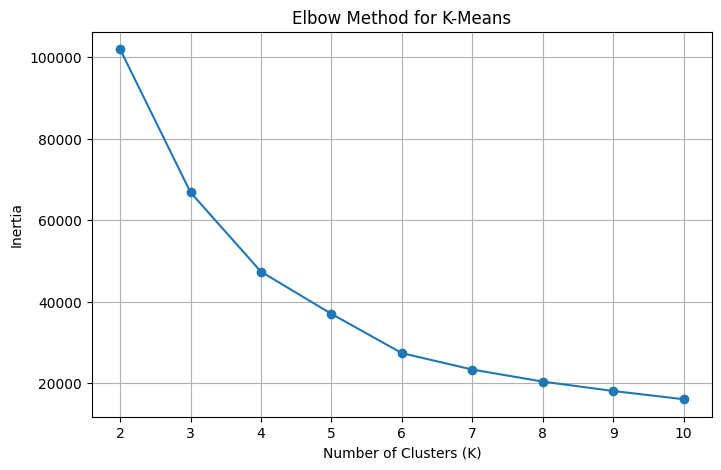

In [31]:
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.grid(True)
plt.show()

i used the elbow method to help choose a suitable value for k instead of selecting one randomly. based on the graph, the biggest decrease in inertia happens between k = 2 and k = 4. after k = 4, the curve starts to flatten, meaning that adding more clusters only gives a small improvement. because of this, i decided to use **k = 4** for the k-means clustering. this follows what we learned in the labs, where the elbow point represents a good balance between keeping the clusters meaningful while avoiding unnecessary complexity.

## 6.4 apply k-means clustering

In [32]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["kmeans_cluster"] = kmeans.fit_predict(geo_scaled)

print("Number of businesses in each cluster:")
print(df["kmeans_cluster"].value_counts().sort_index())

Number of businesses in each cluster:
kmeans_cluster
0    16835
1    15554
2    45019
3     8530
Name: count, dtype: int64


i applied k-means clustering using **k = 4**, which was selected using the elbow method. the algorithm assigned every business to one of the four geographic clusters. the cluster sizes are different, with cluster 2 containing the largest number of businesses. this is expected because businesses are not evenly distributed across the city, and k-means groups locations based on their geographic similarity rather than trying to create clusters with the same number of records.

## 6.5 visualize k-means clusters

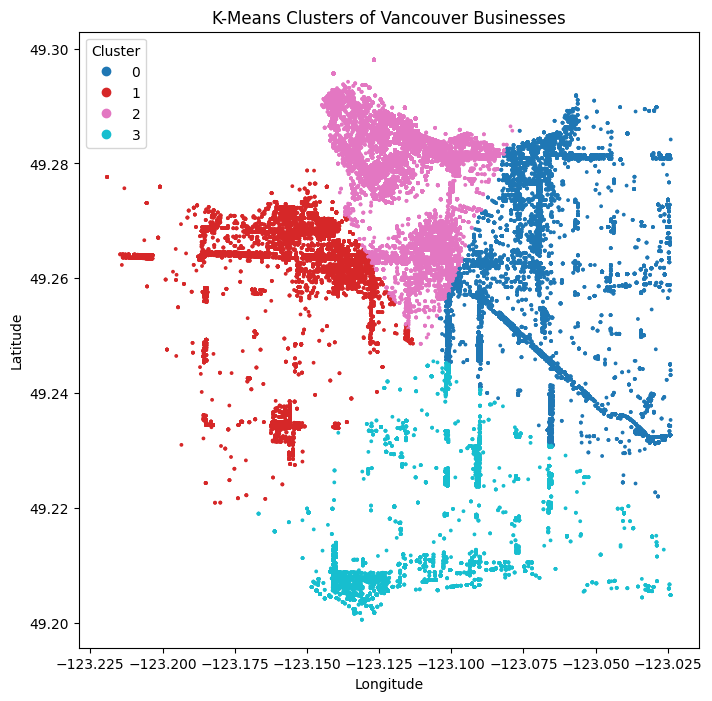

In [35]:
plt.figure(figsize=(8,8))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["kmeans_cluster"],
    cmap="tab10",
    s=3
)

plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title("K-Means Clusters of Vancouver Businesses")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [34]:
import plotly.express as px

fig = px.scatter_map(
    df,
    lat="latitude",
    lon="longitude",
    color="kmeans_cluster",
    zoom=10,
    height=700,
    title="K-Means Clusters"
)

fig.show()


i decided to include both a scatter plot and an interactive map because they each show the clustering results in a different way. the scatter plot makes it easier to see the overall cluster boundaries, while the interactive map helps relate the clusters to their real-world locations across vancouver. based on these visualizations, the four clusters appear to be mostly well separated, with only a small amount of overlap near the edges. overall, the results suggest that k-means successfully grouped businesses that are geographically close together.